# Data Preprocessing Tools

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [18]:
# Importing the dataset from a CSV file
dataset = pd.read_csv('Data.csv')

# Extracting the independent variables (all columns except the last one)
X = dataset.iloc[:, :-1].values

# Extracting the dependent variable (the last column)
y = dataset.iloc[:, -1].values

In [20]:
# Displays the first 5 rows of the dataset by default
dataset.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes


In [21]:
# Provides a statistical summary of the dataset's numerical columns
dataset.describe()

,Age,Salary
count,9.000000,9.000000
mean,38.777778,63777.777778
std,7.693793,12265.579662
min,27.000000,48000.000000
25%,35.000000,54000.000000
50%,38.000000,61000.000000
75%,44.000000,72000.000000
max,50.000000,83000.000000


In [9]:
# Displaying information about the dataset, including column names, non-null counts, and data types
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 448.0+ bytes


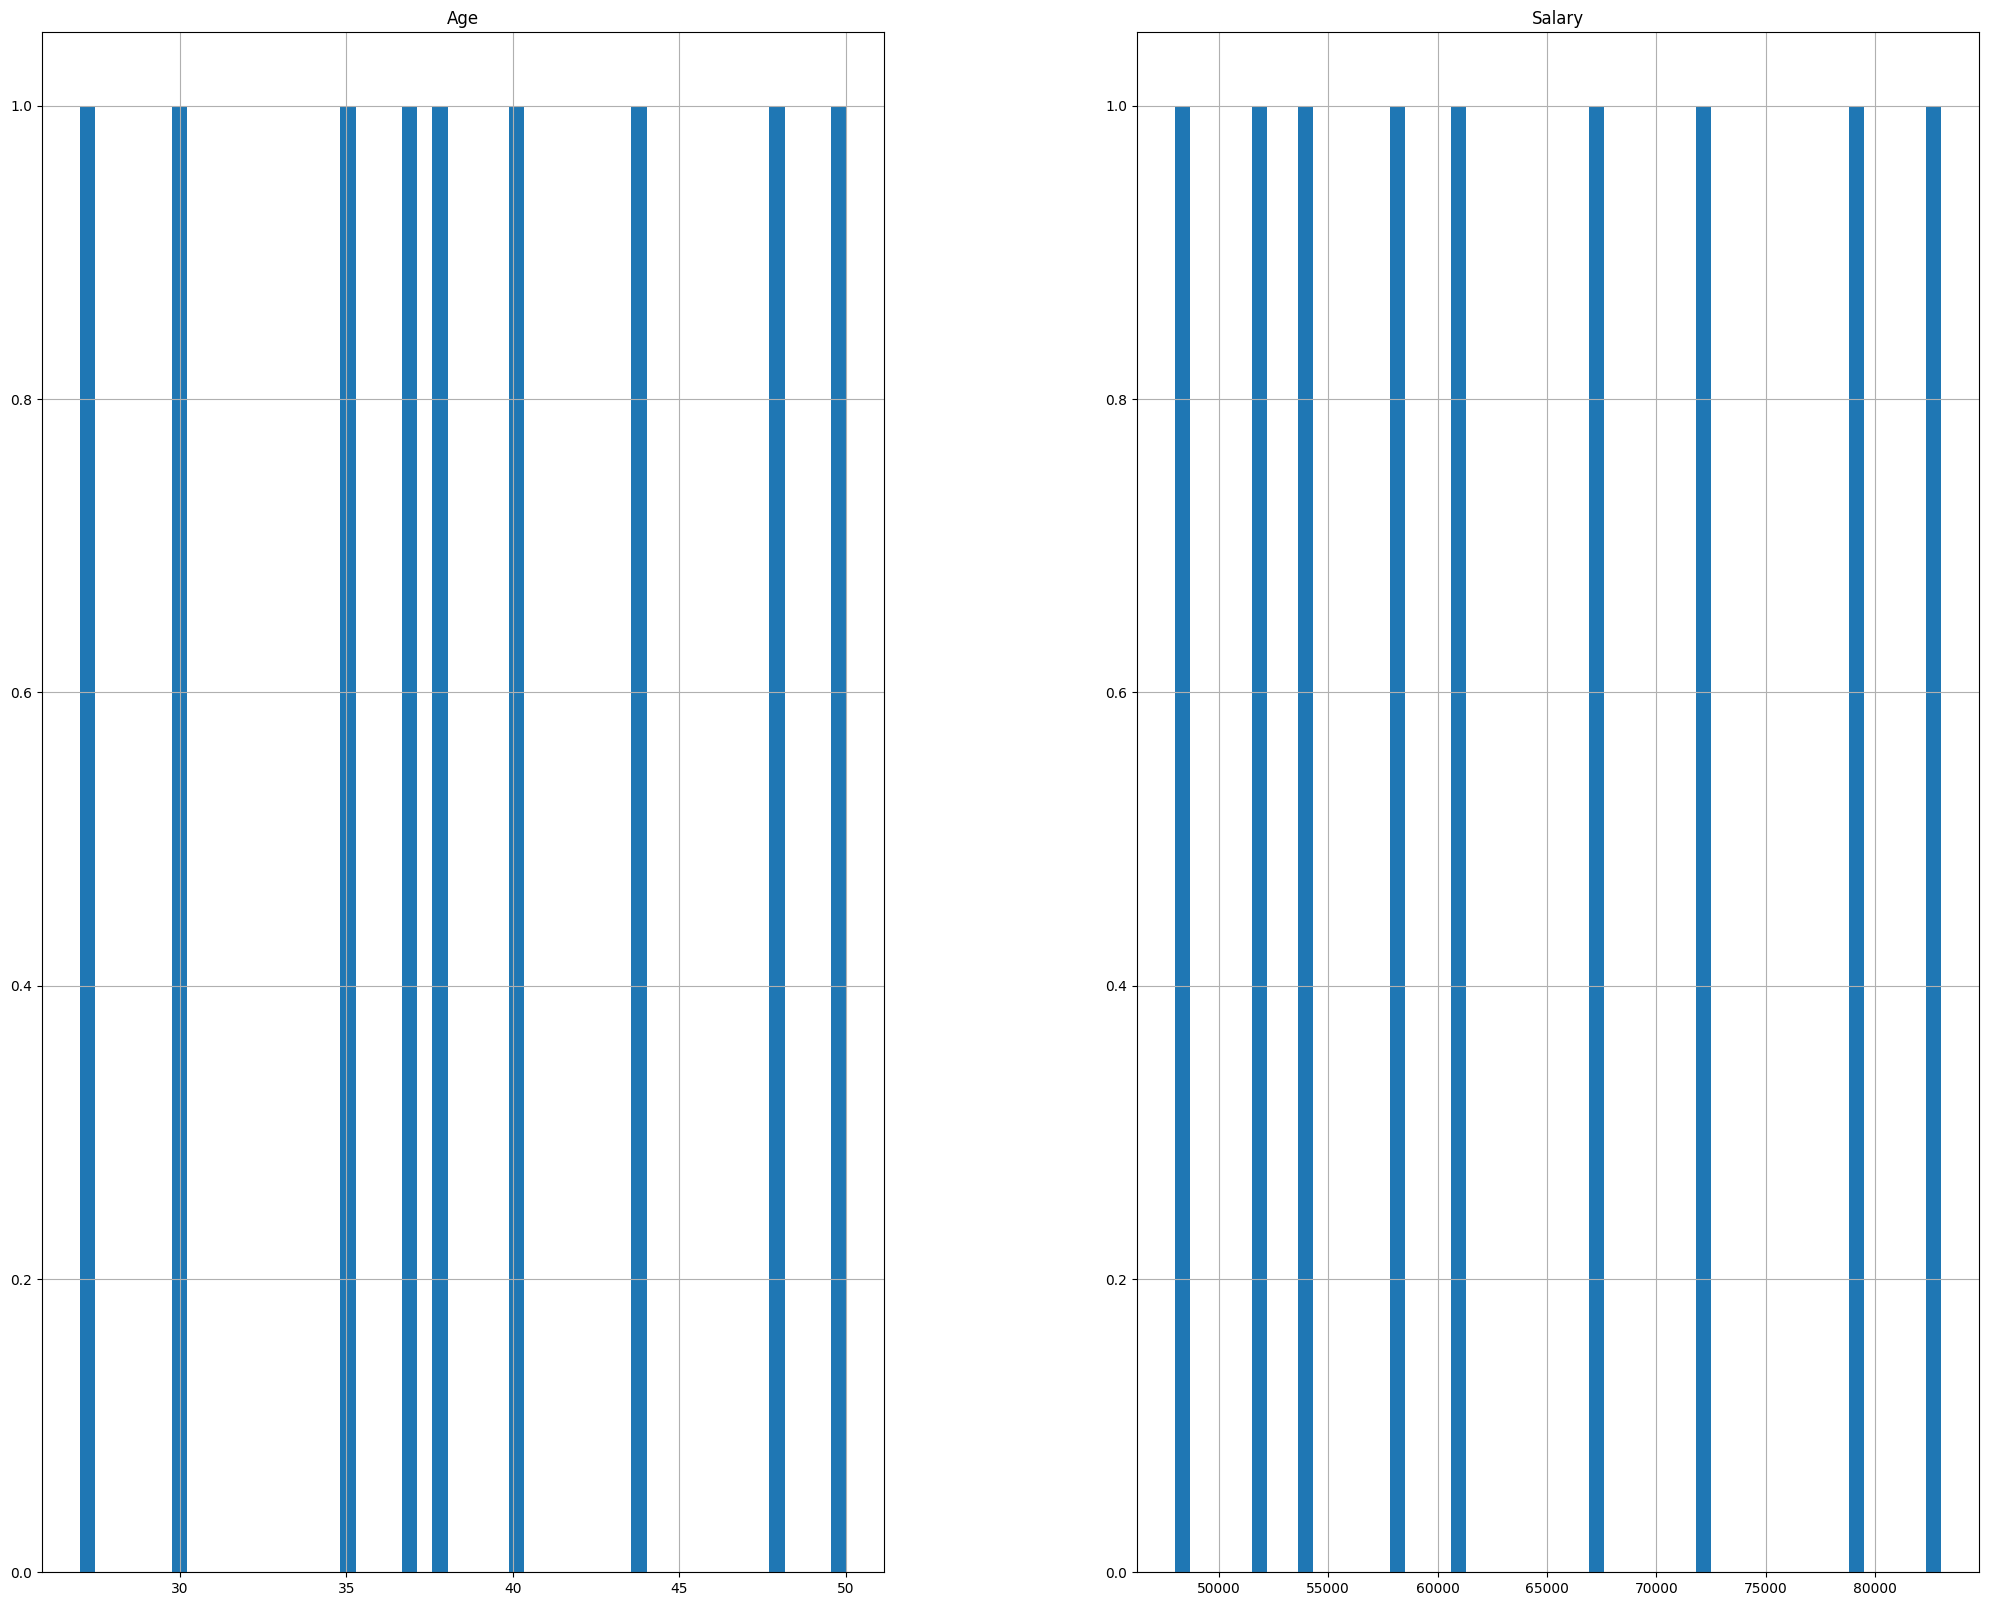

In [23]:
# Generates histograms for each numeric column in the dataset with 50 bins, and sets the figure size
dataset.hist(bins=50, figsize=(25, 20))

# Displays the histograms
plt.show()


In [4]:
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 nan]
 ['France' 35.0 58000.0]
 ['Spain' nan 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


In [5]:
print(y)

['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']


In [19]:
# Provides a statistical summary of the dataset, including count, mean, std deviation, min, and percentiles for numerical columns
dataset.describe()

,Age,Salary
count,9.000000,9.000000
mean,38.777778,63777.777778
std,7.693793,12265.579662
min,27.000000,48000.000000
25%,35.000000,54000.000000
50%,38.000000,61000.000000
75%,44.000000,72000.000000
max,50.000000,83000.000000


## Taking care of missing data

In [10]:
# Importing the SimpleImputer class from sklearn to handle missing data
from sklearn.impute import SimpleImputer

# Creating an instance of SimpleImputer to fill missing values with the mean of the column
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

# Fitting the imputer to the 2nd and 3rd columns of the dataset (X[:, 1:3]), where we want to handle missing data
imputer.fit(X[:, 1:3])

# Transforming the data in the 2nd and 3rd columns by replacing missing values with the calculated mean
X[:, 1:3] = imputer.transform(X[:, 1:3])

In [7]:
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 63777.77777777778]
 ['France' 35.0 58000.0]
 ['Spain' 38.77777777777778 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


## Encoding categorical data

### Encoding the Independent Variable

In [11]:
# Importing the necessary classes for column transformation and one-hot encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Creating a ColumnTransformer object to apply one-hot encoding to the first column (index 0)
# 'encoder' is the name given to this transformation, and remainder='passthrough' ensures that the other columns are left unchanged
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')

# Fitting the ColumnTransformer to the dataset and transforming the first column with one-hot encoding
# Converting the transformed data back to a NumPy array
X = np.array(ct.fit_transform(X))


In [12]:
print(X)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 38.77777777777778 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


### Encoding the Dependent Variable

In [13]:
# Importing the LabelEncoder class from sklearn to encode the target variable
from sklearn.preprocessing import LabelEncoder

# Creating an instance of LabelEncoder
le = LabelEncoder()

# Fitting the LabelEncoder to the target variable 'y' and transforming it into numerical form
y = le.fit_transform(y)


In [ ]:
print(y)

[0 1 0 0 1 1 0 1 0 1]


## Splitting the dataset into the Training set and Test set

In [14]:
# Importing the train_test_split function from sklearn to split the dataset into training and test sets
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and test sets
# X is the feature matrix, y is the target variable
# test_size=0.2 means 20% of the data will be used for testing, and 80% for training
# random_state=1 ensures the split is reproducible (the same split will occur every time the code is run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [ ]:
print(X_train)

[[0.0 0.0 1.0 38.77777777777778 52000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 35.0 58000.0]]


In [ ]:
print(X_test)

[[0.0 1.0 0.0 30.0 54000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


In [ ]:
print(y_train)

[0 1 0 0 1 1 0 1]


In [ ]:
print(y_test)

[0 1]


## Feature Scaling

In [15]:
# Importing the StandardScaler class from sklearn to perform feature scaling
from sklearn.preprocessing import StandardScaler

# Creating an instance of StandardScaler
sc = StandardScaler()

# Fitting the scaler to the training data (columns from index 3 onward) and transforming it
# This scales the features to have a mean of 0 and a standard deviation of 1
X_train[:, 3:] = sc.fit_transform(X_train[:, 3:])

# Applying the same transformation to the test data (without fitting again) to ensure both datasets are scaled consistently
X_test[:, 3:] = sc.transform(X_test[:, 3:])


In [16]:
print(X_train)

[[0.0 0.0 1.0 -0.19159184384578545 -1.0781259408412425]
 [0.0 1.0 0.0 -0.014117293757057777 -0.07013167641635372]
 [1.0 0.0 0.0 0.566708506533324 0.633562432710455]
 [0.0 0.0 1.0 -0.30453019390224867 -0.30786617274297867]
 [0.0 0.0 1.0 -1.9018011447007988 -1.420463615551582]
 [1.0 0.0 0.0 1.1475343068237058 1.232653363453549]
 [0.0 1.0 0.0 1.4379472069688968 1.5749910381638885]
 [1.0 0.0 0.0 -0.7401495441200351 -0.5646194287757332]]


In [17]:
print(X_test)

[[0.0 1.0 0.0 -1.4661817944830124 -0.9069571034860727]
 [1.0 0.0 0.0 -0.44973664397484414 0.2056403393225306]]
